In [21]:
from sklearn.metrics import *
import numpy as np

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

In [22]:
import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction


# Excel dosyasını oku
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")

# Kolon isimlerini manuel olarak ata (gerekirse)
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']

# Sadece gerekli sütunları al ve sırayı ayarla
df_transformed = df[['SpecGroupId', 'Month', 'Sipariş Mik. (TON)', 'GradeGroup']].copy()

# Kolonları yeniden adlandır (istenilen formatta)
df_transformed.columns = ['unique_id', 'ds', 'y', 'x']
df = df_transformed


df['unique_id'] = df['unique_id'].astype(str)
old_df = df


# Remove rows where y is zero
df['y'] = df['y'].replace(0, 0.01)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()


df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[(df['ds'] >= '2022-01-01') & (df['ds'] <= '2024-06-30')]
test_df = df[(df['ds'] >= '2024-07-01') & (df['ds'] <= '2025-02-28')]

#X_train_df = train_df[X_columns].reset_index(drop=True)
#y_train_df = train_df[y_column].reset_index(drop=True)


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(
    max_epochs=20,
    freq_of_test=1,
    batch_size=4,
    learning_rate=0.001, per_series_lr_multip=1.0,
    lr_scheduler_step_size=10, lr_decay=0.5,
    gradient_clipping_threshold=5,
    rnn_weight_decay=0.0, noise_std=0.001,
    level_variability_penalty=0,        # << yumuşatma etkisini sıfırla
    testing_percentile=10, training_percentile=50,
    ensemble=True, max_periods=70,
    seasonality=[12],                 
    input_size=12,                      # << daha geniş geçmiş
    output_size=8,                      # << daha kısa ileri tahmin
    cell_type='LSTM',
    state_hsize=40,                     # << öğrenme kapasitesi artır
    add_nl_layer=False,
    random_seed=1, device='cpu'
)






# Split into X and y for training and testing
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)

print(y_train_df)
X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]


# Fit the model
model.fit(X_train_df, y_train_df)



print(X_test_df)
y_hat = model.predict(X_test_df)
print(y_hat)



      unique_id         ds      y
0             1 2022-01-01 240.59
1             1 2022-02-01 261.81
2             1 2022-03-01 150.00
3             1 2022-04-01  54.00
4             1 2022-05-01 190.00
...         ...        ...    ...
38365       999 2024-02-01   0.01
38366       999 2024-03-01   0.01
38367       999 2024-04-01   0.01
38368       999 2024-05-01   0.01
38369       999 2024-06-01   0.01

[38370 rows x 3 columns]
Infered frequency: MS
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 2.45595
Training loss (50 prc): 0.84199
========= Epoch 1 finished =========
Training time: 2.41849
Training loss (50 prc): 0.69195
========= Epoch 2 finished =========
Training time: 2.39397
Training loss (50 prc): 0.66630
========= Epoch 3 finished =========
Training time: 2.40165
Training loss (50 prc): 0.65214
========= Epoch 4 finished =========
Training time: 2.39794
Training loss (50 prc): 0.63249
========= Epoch 5 finished ========

In [23]:
"""

import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction


# Excel dosyasını oku
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")

# Kolon isimlerini manuel olarak ata (gerekirse)
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']

# Sadece gerekli sütunları al ve sırayı ayarla
df_transformed = df[['SpecGroupId', 'Month', 'Sipariş Mik. (TON)', 'GradeGroup']].copy()

# Kolonları yeniden adlandır (istenilen formatta)
df_transformed.columns = ['unique_id', 'ds', 'y', 'x']
df = df_transformed


df['unique_id'] = df['unique_id'].astype(str)
old_df = df


# Remove rows where y is zero
df['y'] = df['y'].replace(0, 0.01)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()


df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[(df['ds'] >= '2022-01-01') & (df['ds'] <= '2025-02-28')]


#X_train_df = train_df[X_columns].reset_index(drop=True)
#y_train_df = train_df[y_column].reset_index(drop=True)


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(
    max_epochs=20,
    freq_of_test=1,
    batch_size=4,
    learning_rate=0.001, per_series_lr_multip=1.0,
    lr_scheduler_step_size=10, lr_decay=0.5,
    gradient_clipping_threshold=5,
    rnn_weight_decay=0.0, noise_std=0.001,
    level_variability_penalty=0,        # << yumuşatma etkisini sıfırla
    testing_percentile=10, training_percentile=50,
    ensemble=True, max_periods=70,
    seasonality=[12],                 
    input_size=12,                      # << daha geniş geçmiş
    output_size=3,                      # << daha kısa ileri tahmin
    cell_type='LSTM',
    state_hsize=40,                     # << öğrenme kapasitesi artır
    add_nl_layer=False,
    random_seed=1, device='cpu'
)






# Split into X and y for training and testing
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)


# Fit the model
model.fit(X_train_df, y_train_df)

# Benzersiz ID ve Grade bilgilerini al
unique_ids = df[['unique_id', 'x']].drop_duplicates()

# Tahmin yapılacak ileri tarih aralığı
future_dates = pd.date_range(start='2025-03-01', end='2025-05-01', freq='MS')  # Month Start

# Yeni test seti oluştur (cartesian product)
X_future_df = pd.DataFrame([
    {'unique_id': uid, 'x': grade, 'ds': date}
    for uid, grade in unique_ids.to_records(index=False)
    for date in future_dates
])

# Sıralama (opsiyonel)
X_future_df = X_future_df.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

# 3 aylık ileri tahmin üret
y_future_hat = model.predict(X_future_df)

y_future_hat = y_future_hat.rename(columns={
    'unique_id': 'SpecGroupId',
    'x': 'GradeGroup',
    'ds': 'Month',
    'y_hat': 'Forecast_TON'
})

# İstenen sıraya göre sütunları yeniden düzenle
y_future_hat = y_future_hat[['Month', 'GradeGroup', 'SpecGroupId', 'Forecast_TON']]

# Excel'e kaydet
y_future_hat.to_excel('../results/ESRNN_forecast.xlsx', index=False)
"""

'\n\nimport pandas as pd\nfrom ESRNN import ESRNN\nfrom ESRNN.utils_evaluation import evaluate_prediction_owa\nfrom ESRNN.utils_visualization import plot_grid_prediction\n\n\n# Excel dosyasını oku\ndf = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")\n\n# Kolon isimlerini manuel olarak ata (gerekirse)\ndf.columns = [\'Month\', \'SpecGroupId\', \'Grade\', \'Sipariş Mik. (TON)\', \'GradeGroup\']\n\n# Sadece gerekli sütunları al ve sırayı ayarla\ndf_transformed = df[[\'SpecGroupId\', \'Month\', \'Sipariş Mik. (TON)\', \'GradeGroup\']].copy()\n\n# Kolonları yeniden adlandır (istenilen formatta)\ndf_transformed.columns = [\'unique_id\', \'ds\', \'y\', \'x\']\ndf = df_transformed\n\n\ndf[\'unique_id\'] = df[\'unique_id\'].astype(str)\nold_df = df\n\n\n# Remove rows where y is zero\ndf[\'y\'] = df[\'y\'].replace(0, 0.01)\n\nzero_mask = df[\'y\'] == 0\nnum_zeros = zero_mask.sum()\n\n\ndf = df.sort_values(by=["unique_id", "ds"])\n\n#df[\'y\'] = 50*df[\'y\']

In [24]:
comparison_df = y_hat.merge(y_test_df, on=['unique_id', 'ds'], how='left')
print(comparison_df)
def save_datasets(comparison_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    #comparison_df.to_csv(f"{folder_path}comparison_df.csv", index=False)

    #print(f"Data saved in '{folder_path}' before running the model.")

# Save Data Before Running the Model
#save_datasets(comparison_df)

print(y_hat)

      unique_id         ds       x  y_hat     y
0             1 2024-07-01       A   5.10 54.27
1             1 2024-08-01       A   8.28 20.00
2             1 2024-09-01       A  18.27 40.00
3             1 2024-10-01       A   3.80  0.01
4             1 2024-11-01       A   8.96  0.01
...         ...        ...     ...    ...   ...
10227       999 2024-10-01  S235JR   0.01  0.01
10228       999 2024-11-01  S235JR   0.01  0.01
10229       999 2024-12-01  S235JR   0.01  0.01
10230       999 2025-01-01  S235JR   0.01  0.01
10231       999 2025-02-01  S235JR   0.01  0.01

[10232 rows x 5 columns]
      unique_id         ds       x  y_hat
0             1 2024-07-01       A   5.10
1             1 2024-08-01       A   8.28
2             1 2024-09-01       A  18.27
3             1 2024-10-01       A   3.80
4             1 2024-11-01       A   8.96
...         ...        ...     ...    ...
10227       999 2024-10-01  S235JR   0.01
10228       999 2024-11-01  S235JR   0.01
10229       999 2024

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Önce gerçek verileri filtrele
filtered_true = y_test_df[y_test_df['y'] > -0.01][['unique_id', 'ds', 'y']]

# Tahmin edilen verileri al
pred_df = y_hat[['unique_id', 'ds', 'y_hat']]

# Hem unique_id hem de Month'a göre eşleşen verileri merge ile bul
merged_df = pd.merge(filtered_true, pred_df, on=['unique_id', 'ds'], how='inner')

# Elde edilen eşleşmiş değerlerle metrikleri hesapla
y_true = merged_df['y']
y_pred = merged_df['y_hat']

mae_filtered = mean_absolute_error(y_true, y_pred)
mape_filtered = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse_filtered = np.sqrt(mean_squared_error(y_true, y_pred))
smape_filtered = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape_filtered = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# Sonuçları yazdır
print(f"Eşleşen satır sayısı: {len(merged_df)}")
print(f"📉 Filtrelenmiş MAE   : {mae_filtered:.4f}")
print(f"📊 Filtrelenmiş MAPE  : {mape_filtered:.2f}%")
print(f"📐 Filtrelenmiş RMSE  : {rmse_filtered:.4f}")
print(f"🔁 Filtrelenmiş sMAPE : {smape_filtered:.2f}%")
print(f"⚖️  Filtrelenmiş wMAPE : {wmape_filtered:.2f}%")

# Sonucu Excel'e kaydetmek istersen
#merged_df.to_excel("matched_y_true_vs_y_hat.xlsx", index=False)




Eşleşen satır sayısı: 10232
📉 Filtrelenmiş MAE   : 27.5085
📊 Filtrelenmiş MAPE  : 8774.94%
📐 Filtrelenmiş RMSE  : 183.7920
🔁 Filtrelenmiş sMAPE : 68.18%
⚖️  Filtrelenmiş wMAPE : 68.73%


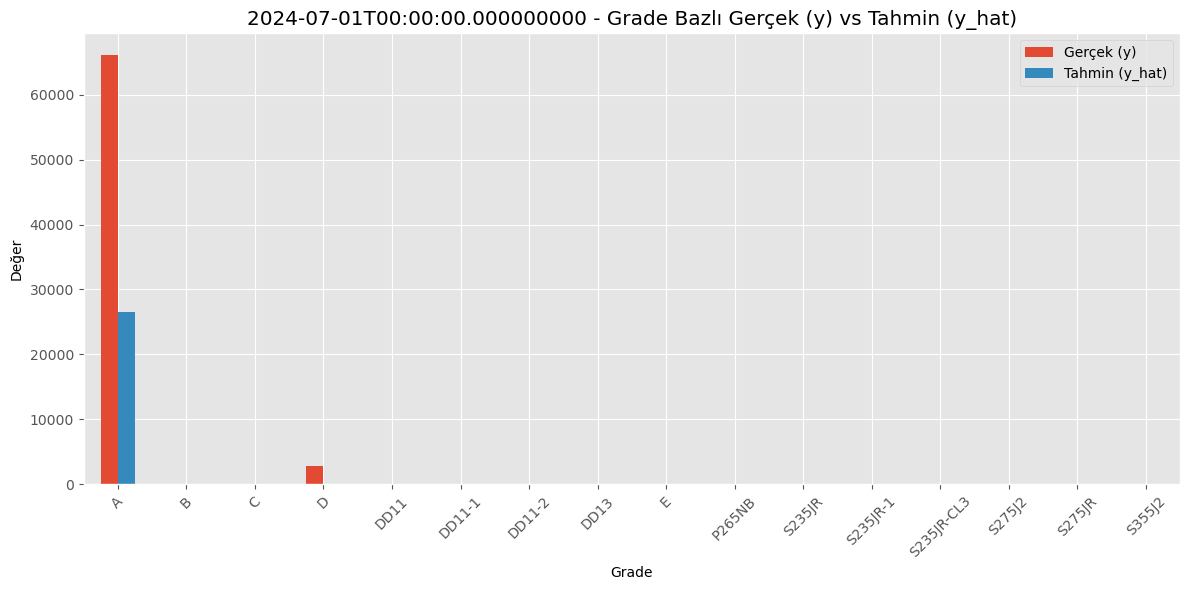

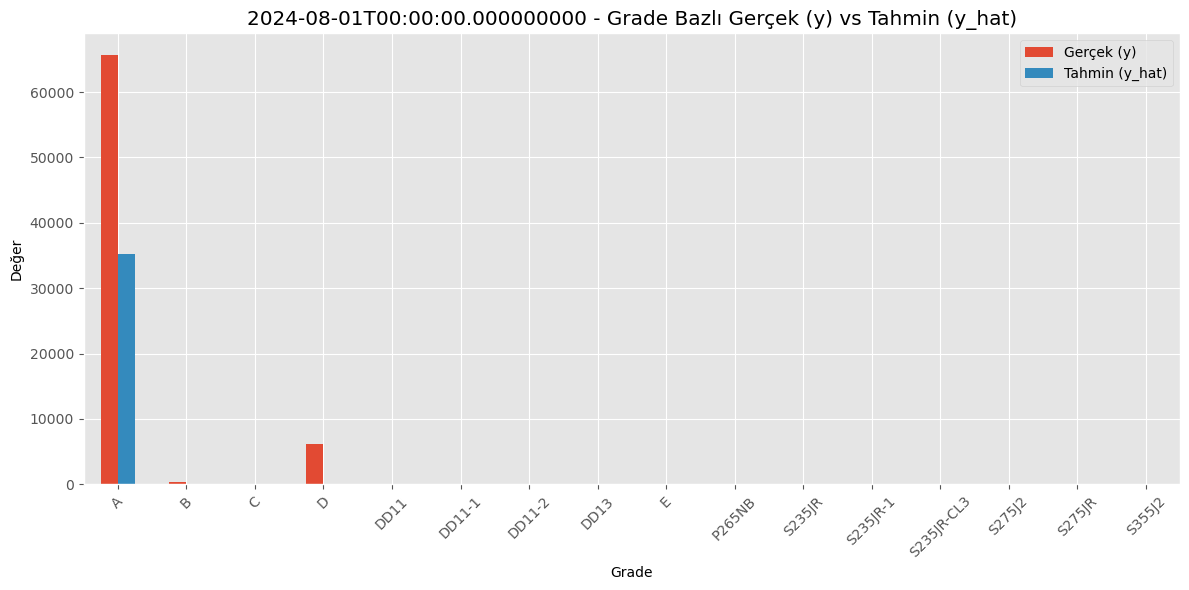

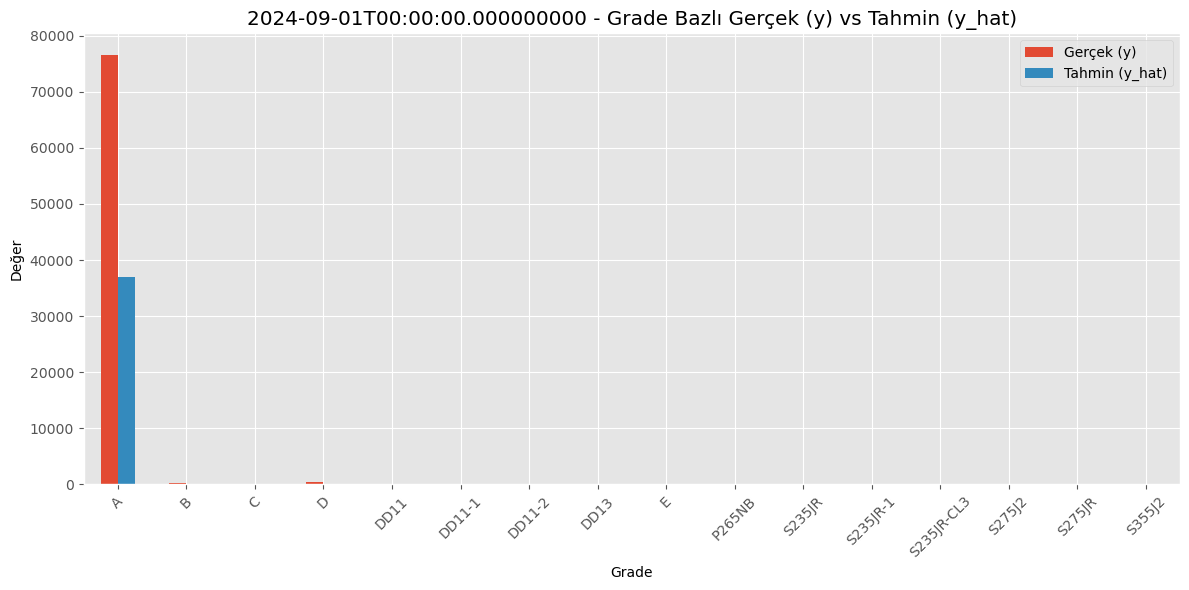

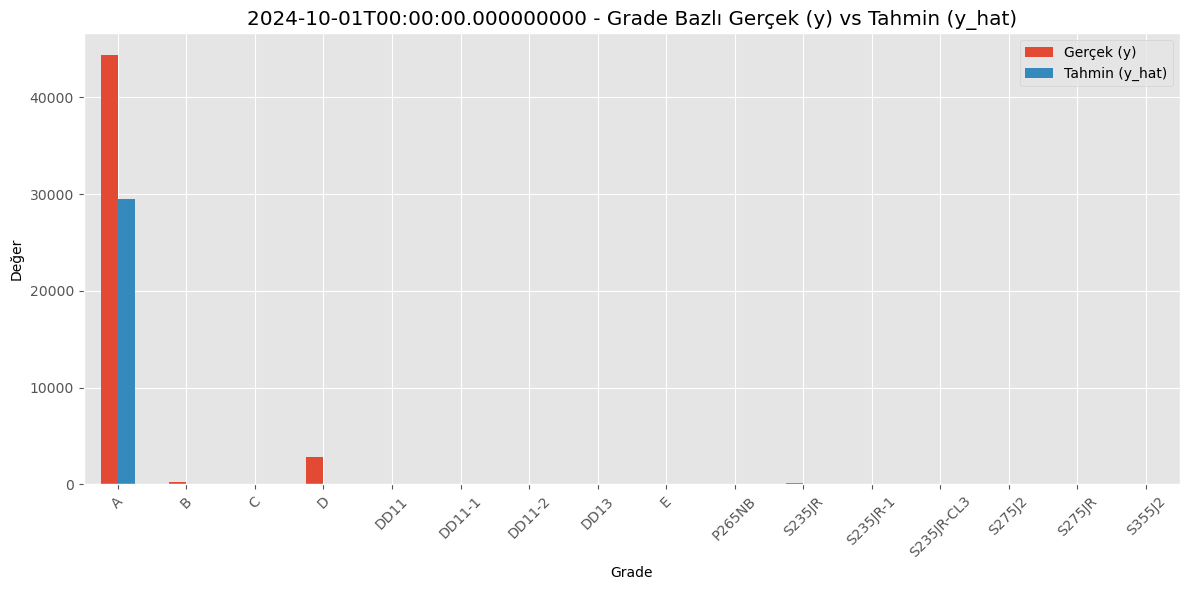

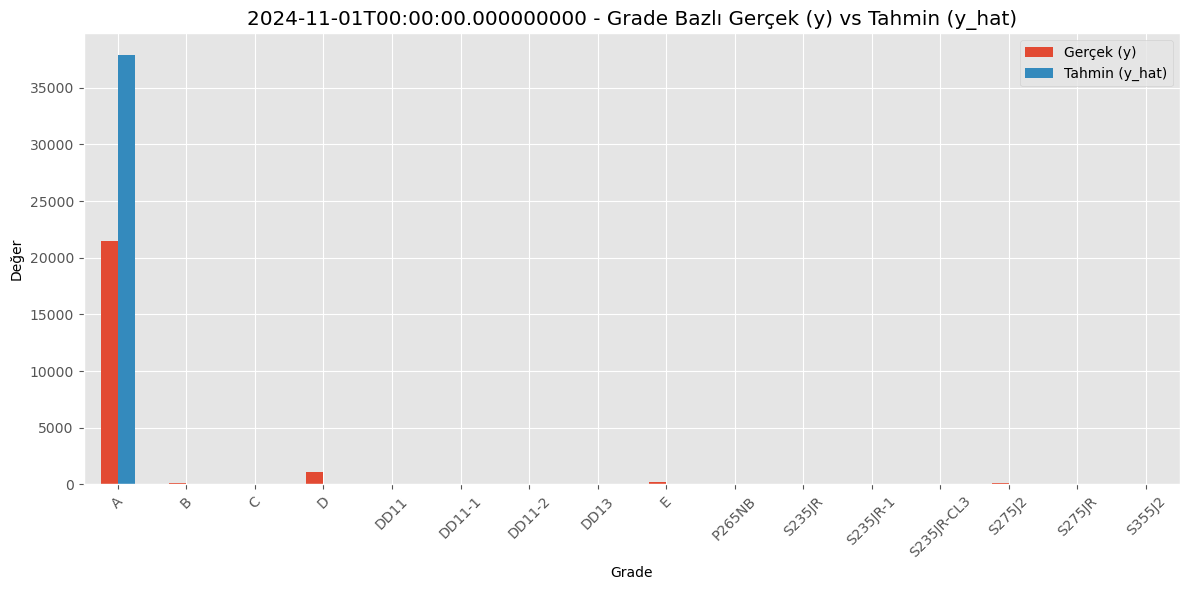

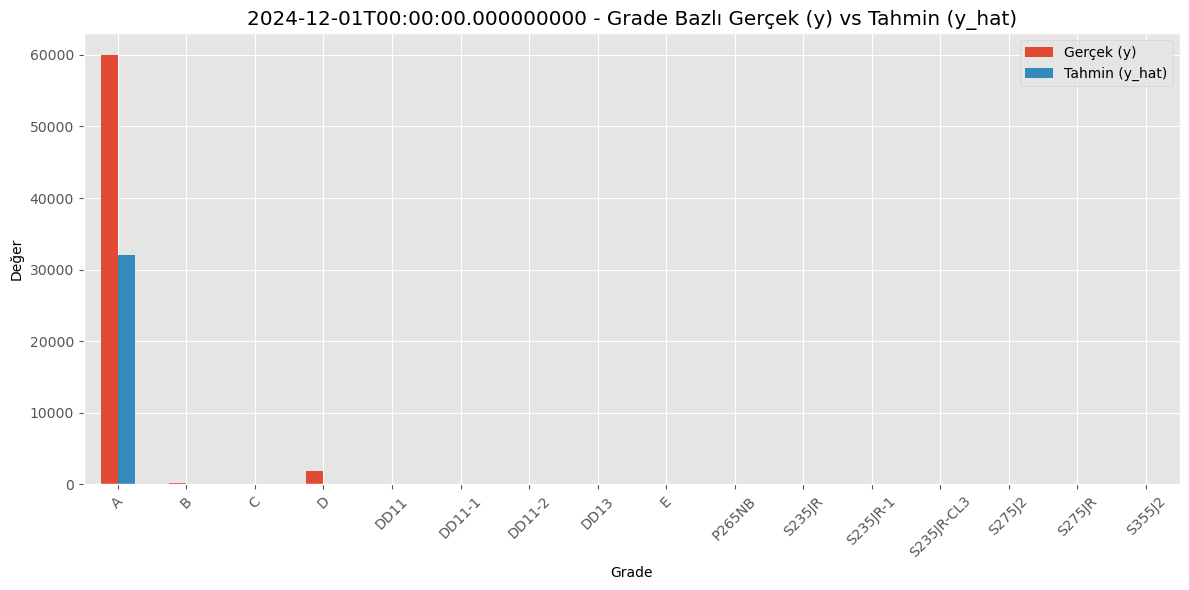

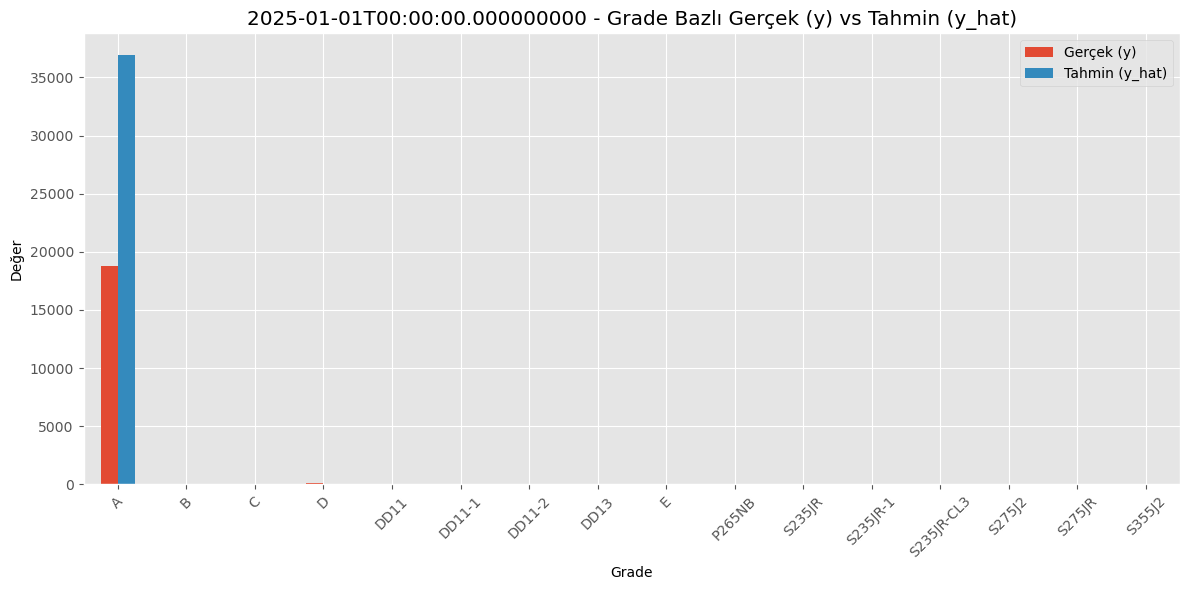

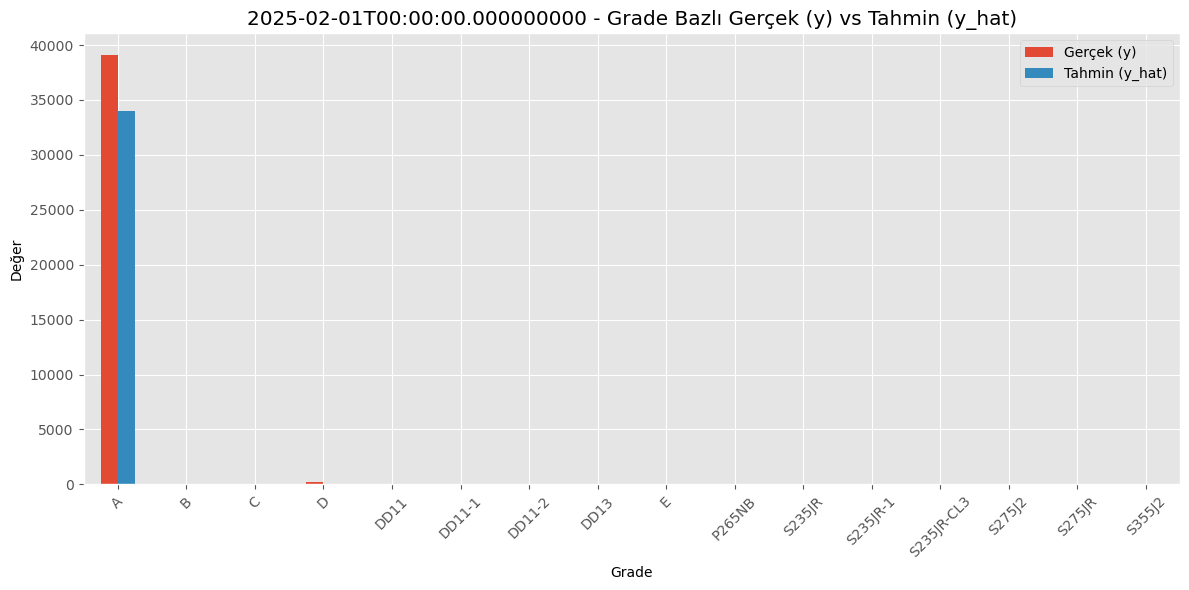

In [26]:

# unique_id ve ds'e göre left join
merged_df = pd.merge(y_test_df, y_hat, on=['unique_id', 'ds'], how='left')
mergeeee = merged_df
aggregated_df_y_hat = merged_df.groupby(['ds', 'x'])['y_hat'].sum().reset_index()

aggregated_df_y = merged_df.groupby(['ds', 'x'])['y'].sum().reset_index()

import pandas as pd
import matplotlib.pyplot as plt

# Ortaklaştır
merged_df = pd.merge(aggregated_df_y, aggregated_df_y_hat, on=['ds', 'x'], how='inner')

# Her ay (ds) için ayrı grafik çiz
for ds_value in merged_df['ds'].unique():
    subset = merged_df[merged_df['ds'] == ds_value].set_index('x')
    
    subset[['y', 'y_hat']].plot(kind='bar', figsize=(12, 6))
    plt.title(f"{ds_value} - Grade Bazlı Gerçek (y) vs Tahmin (y_hat)")
    plt.ylabel("Değer")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Gerçek (y)", "Tahmin (y_hat)"])
    plt.tight_layout()
    plt.show()



In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🔹 1. Grade + Ay (ds + x) bazında toplam
grade_monthly = mergeeee.groupby(['ds', 'x']).agg({'y': 'sum', 'y_hat': 'sum'}).reset_index()

# 🔹 2. Tüm Grade + Ay bazlı değerleri düz liste haline getir
y_true = grade_monthly['y'].values
y_pred = grade_monthly['y_hat'].values

# 🔹 3. Error metric hesaplamaları
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# 🔥 Sonucu yazdıralım
print(f"\n📦 (Grade + Ay Bazlı) Toplam Performans:")
print(f"MAE   : {mae:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"wMAPE : {wmape:.2f}%")
print(f"RMSE  : {rmse:.4f}")





📦 (Grade + Ay Bazlı) Toplam Performans:
MAE   : 1637.4439
MAPE  : 55.51%
sMAPE : 60.50%
wMAPE : 51.18%
RMSE  : 6705.8486


In [28]:
# Filtreleme koşulu
filtered_indices = y_test_df['y'] > 0.1

# Yalnızca koşula uyan gerçek değerleri seç
filtered_y_true = y_test_df.loc[filtered_indices, 'y']

# Ortak indexlerde kesişim yaparak tahmin değerlerini seç
common_indices = filtered_y_true.index.intersection(y_hat.index)

# Ortak indexler ile filtrelenmiş değerler
filtered_y_true = y_test_df.loc[common_indices, 'y']
filtered_y_pred = y_hat.loc[common_indices, 'y_hat']
filtered_unique_ids = y_test_df.loc[common_indices, 'unique_id']

# Sonuçları içeren DataFrame oluştur
filtered_results_df = pd.DataFrame({
    'unique_id': filtered_unique_ids,
    'y_true': filtered_y_true,
    'y_predicted': filtered_y_pred
})

# Excel dosyasına kaydet
#filtered_results_df.to_excel('filtered_true_vs_predicted_with_id.xlsx', index=False)


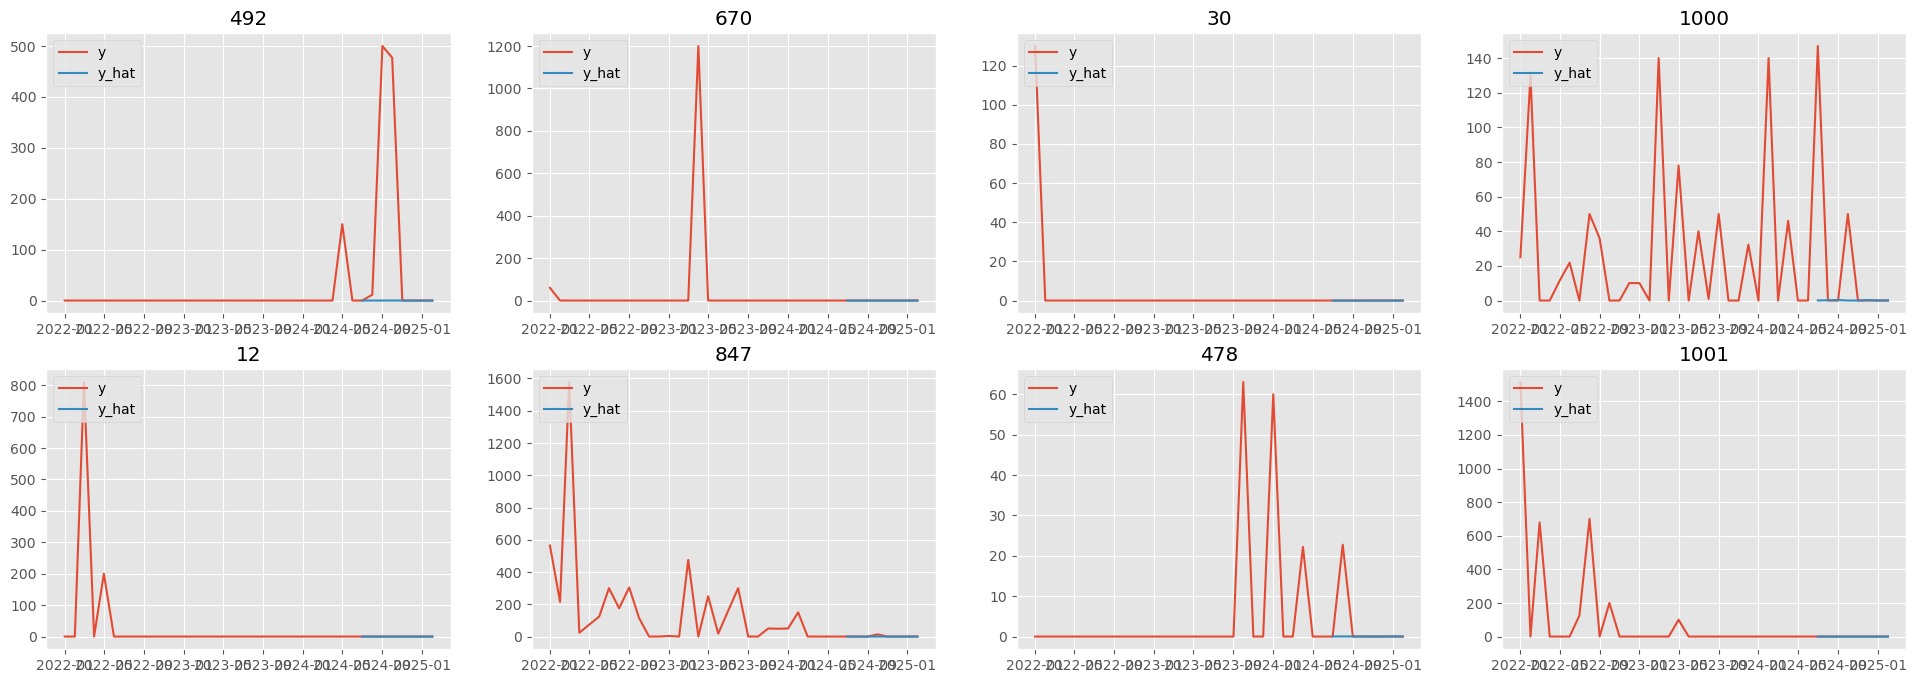

In [29]:
unique_ids = ['670', '847','478','492','12','30','1000','1001']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat,  unique_ids=unique_ids)

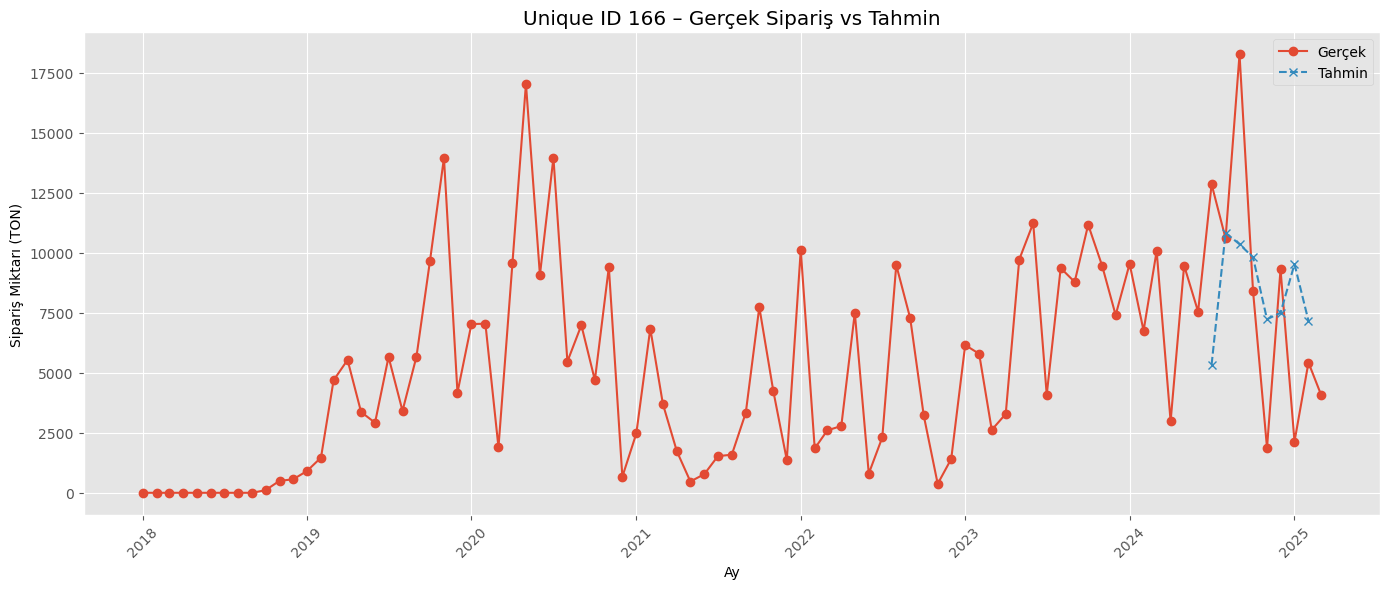

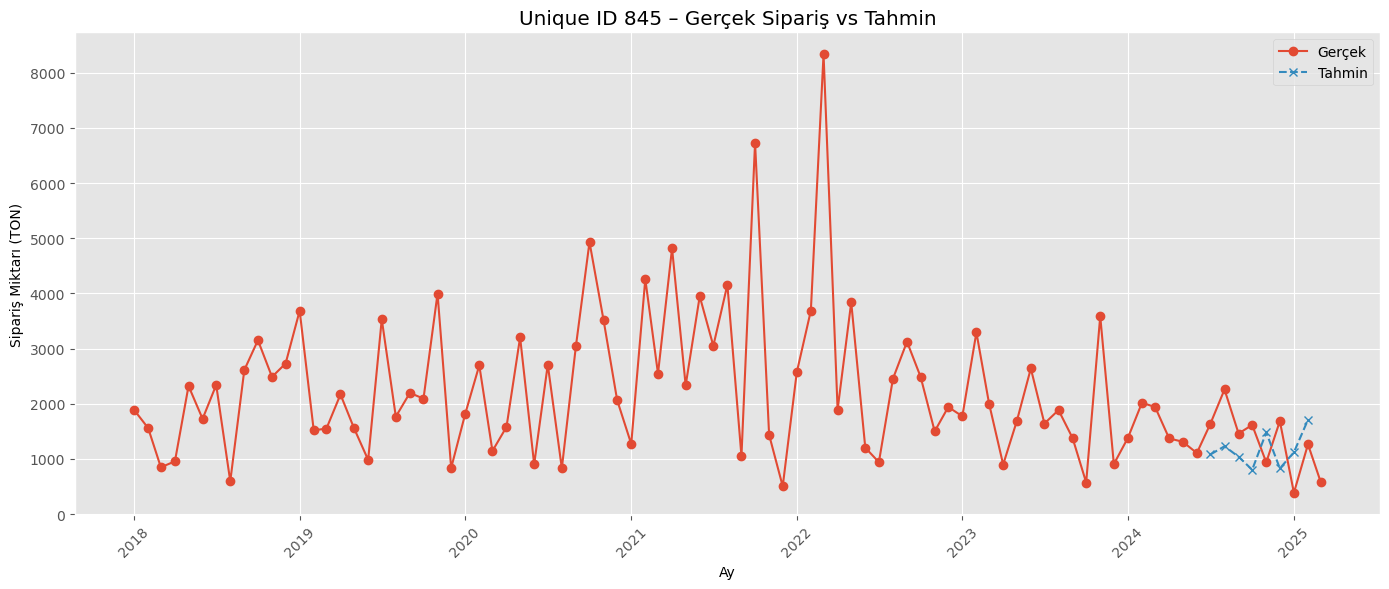

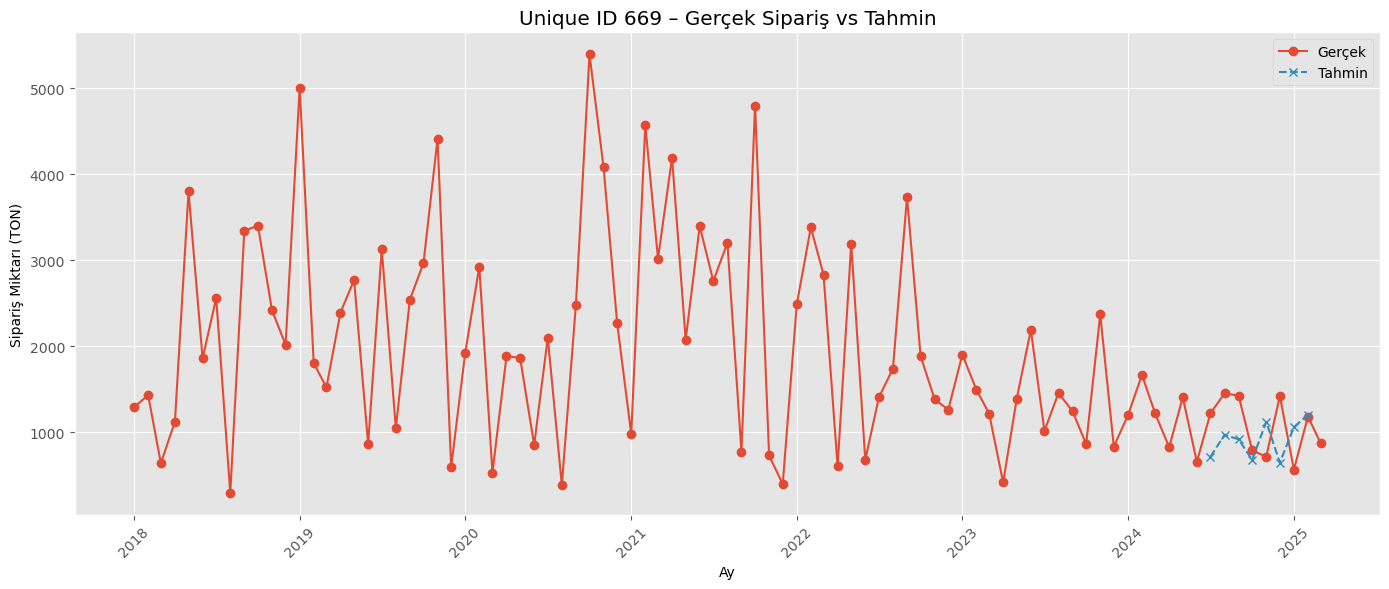

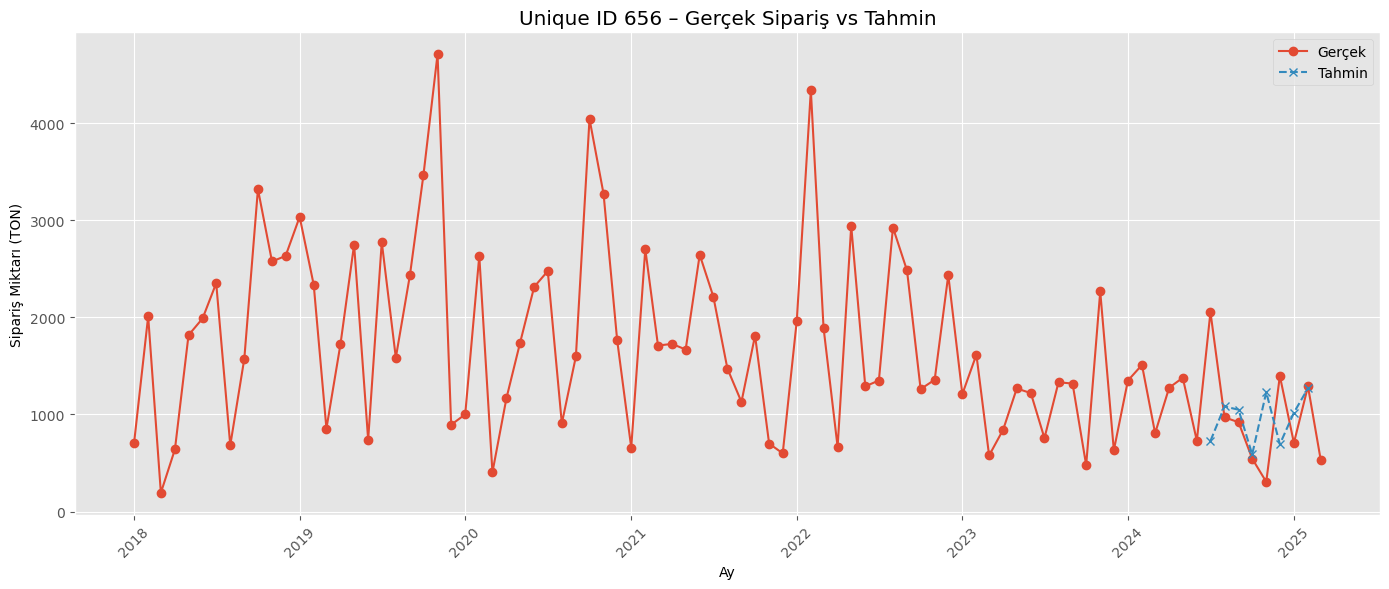

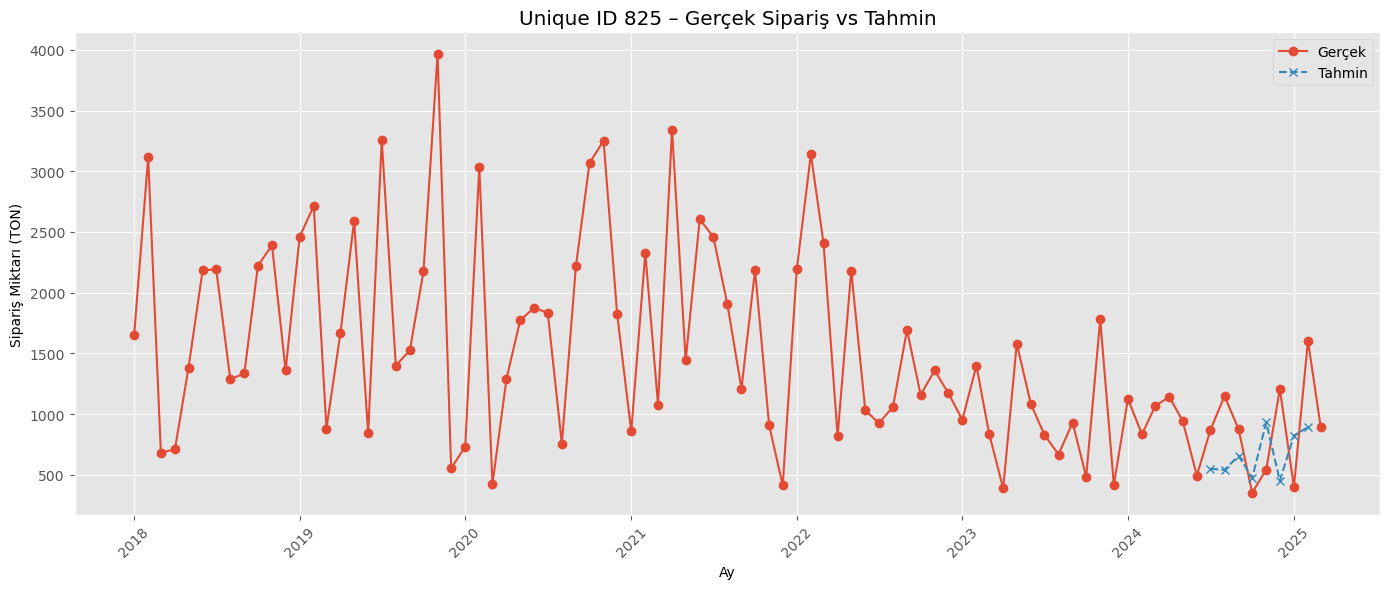

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 🎯 Seçmek istediğin unique_id’leri belirle
selected_ids = ['166', '845', '669','656','825']  # ilgilendiğin ID'leri yaz

for uid in selected_ids:
    # 🔹 Gerçek veriler (old_df)
    actual_series = old_df[old_df['unique_id'] == uid][['ds', 'y']].copy()
    actual_series.set_index('ds', inplace=True)
    actual_series.rename(columns={'y': 'Actual'}, inplace=True)

    # 🔹 Tahmin veriler (mergeeee)
    forecast_series = mergeeee[mergeeee['unique_id'] == uid][['ds', 'y_hat']].copy()
    forecast_series.set_index('ds', inplace=True)
    forecast_series.rename(columns={'y_hat': 'Forecast'}, inplace=True)

    # 🔗 Ay atlamadan birleştir
    all_dates = pd.date_range(start=min(actual_series.index.min(), forecast_series.index.min()),
                              end=max(actual_series.index.max(), forecast_series.index.max()),
                              freq='MS')

    full_df = pd.DataFrame(index=all_dates)
    full_df = full_df.join(actual_series)
    full_df = full_df.join(forecast_series)

    # 📈 Grafik çizimi
    plt.figure(figsize=(14, 6))
    plt.plot(full_df.index, full_df['Actual'], label='Gerçek', marker='o')
    plt.plot(full_df.index, full_df['Forecast'], label='Tahmin', linestyle='--', marker='x')
    plt.title(f"Unique ID {uid} – Gerçek Sipariş vs Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()





In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🎯 Seçmek istediğin unique_id’leri belirle
selected_ids = ['166', '845', '669','656','825']

# Sonuçları saklamak için boş DataFrame
metrics_df = pd.DataFrame(columns=['UniqueID', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for uid in selected_ids:
    # 🔹 İlgili unique_id'ye göre veri seç
    df_selected = mergeeee[mergeeee['unique_id'] == uid].copy()
    df_selected = df_selected.dropna(subset=['y', 'y_hat'])  # NaN varsa temizle

    y_true = df_selected['y']
    y_pred = df_selected['y_hat']

    # 📐 Hata metriklerini hesapla
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    # Sonuçları ekle
    metrics_df = pd.concat([metrics_df, pd.DataFrame({
        'UniqueID': [uid],
        'MAE': [mae],
        'MAPE (%)': [mape],
        'sMAPE (%)': [smape],
        'wMAPE (%)': [wmape],
        'RMSE': [rmse]
    })], ignore_index=True)

# 📊 Sonuçları göster
print(metrics_df)



  UniqueID      MAE  MAPE (%)  sMAPE (%)  wMAPE (%)     RMSE
0      166 4,171.79    100.63      56.16      48.46 5,133.66
1      845   674.82     61.48      55.10      47.96   704.71
2      669   411.60     40.32      41.28      37.45   468.86
3      656   446.03     61.86      44.01      43.56   635.88
4      825   443.50     54.08      55.58      50.61   492.77


In [32]:
# Function to save datasets
def save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    X_train_df.to_csv(f"{folder_path}X_train_df.csv", index=False)
    y_train_df.to_csv(f"{folder_path}y_train_df.csv", index=False)
    X_test_df.to_csv(f"{folder_path}X_test_df.csv", index=False)
    y_test_df.to_csv(f"{folder_path}y_test_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Ensure Data Is Clean Before Saving
X_train_df = X_train_df.dropna().reset_index(drop=True)
y_train_df = y_train_df.dropna().reset_index(drop=True)
X_test_df = X_test_df.dropna().reset_index(drop=True)
y_test_df = y_test_df.dropna().reset_index(drop=True)

# Save Data Before Running the Model
#save_datasets(X_train_df, y_train_df, X_test_df, y_test_df)

In [33]:
# Generate forecasts
forecasts = model.predict(X_test_df, y_test_df)
print(forecasts[:1000])

    unique_id         ds  x  y_hat
0           1 2024-07-01  A   5.10
1           1 2024-08-01  A   8.28
2           1 2024-09-01  A  18.27
3           1 2024-10-01  A   3.80
4           1 2024-11-01  A   8.96
..        ...        ... ..    ...
995       111 2024-10-01  A   0.02
996       111 2024-11-01  A   0.02
997       111 2024-12-01  A   0.04
998       111 2025-01-01  A   0.03
999       111 2025-02-01  A   0.05

[1000 rows x 4 columns]
